<a href="https://colab.research.google.com/github/AD-lone-maverick/Earthquake-magnitude-Prediction-Model/blob/main/DELTA_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving query (7).csv to query (7).csv
Data Overview:
                       time  latitude  longitude   depth  mag magType   nst  \
0  2025-11-16T13:19:32.959Z   39.6051   143.5732  10.000  4.5      mb  93.0   
1  2025-11-15T18:06:22.756Z   39.7006   143.1899  25.681  4.7      mb  89.0   
2  2025-11-15T13:31:45.230Z   45.4818   150.8097  47.946  4.5      mb  36.0   
3  2025-11-14T17:34:53.745Z   37.3022   141.9915  22.056  4.7      mb  88.0   
4  2025-11-14T15:01:54.083Z   37.0946   141.8347  57.278  4.7      mb  25.0   

     gap   dmin   rms  ...                   updated  \
0  132.0  2.256  0.60  ...  2025-11-16T14:00:54.040Z   
1   92.0  1.957  0.49  ...  2025-11-15T18:59:54.040Z   
2  179.0  5.777  0.58  ...  2025-11-15T14:29:14.040Z   
3  131.0  3.127  0.94  ...  2025-11-14T19:15:13.040Z   
4  150.0  2.961  0.62  ...  2025-11-14T15:25:30.040Z   

                          place        type horizontalError depthError  \
0     140 km E of Miyako, Japan  earthquake            8.33  

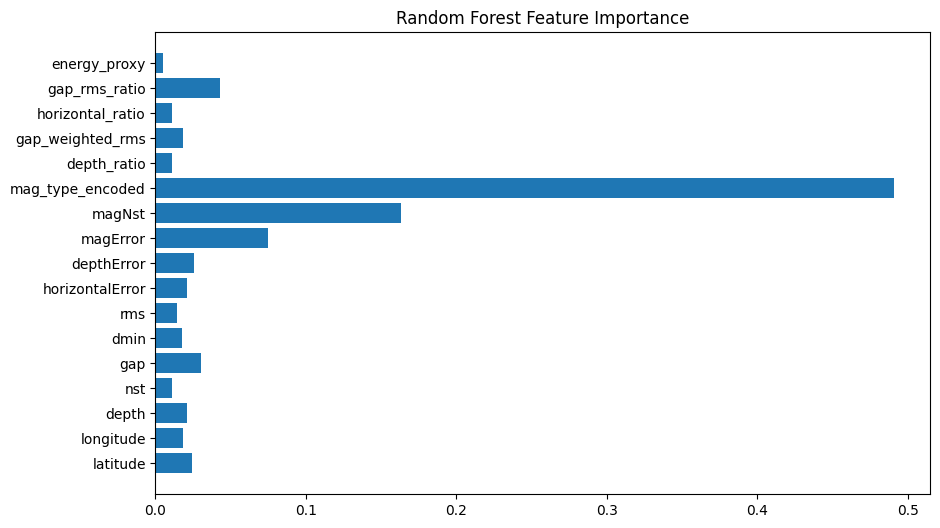

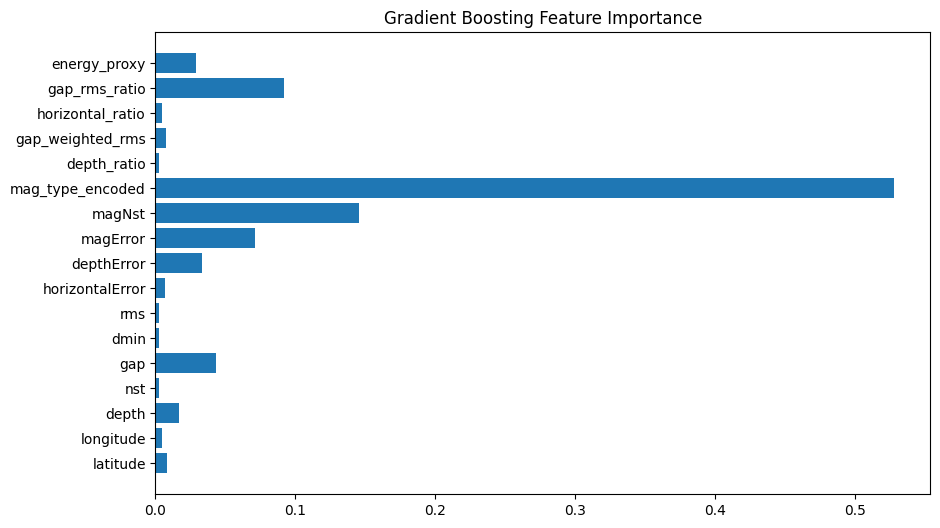

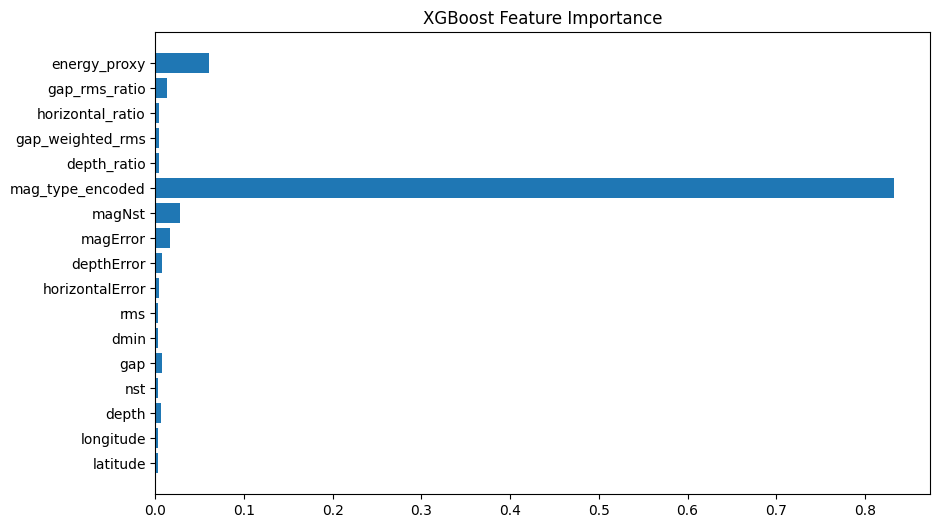

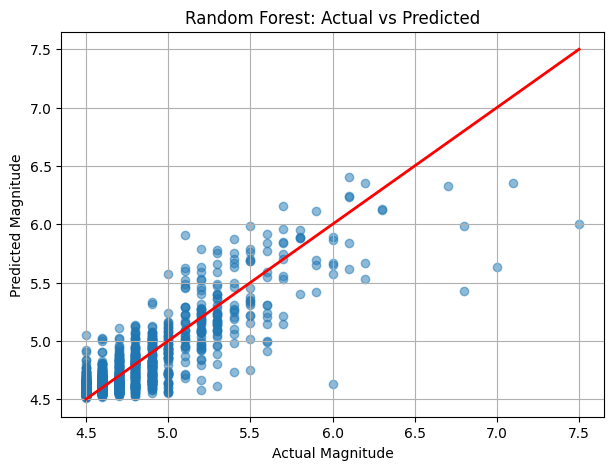

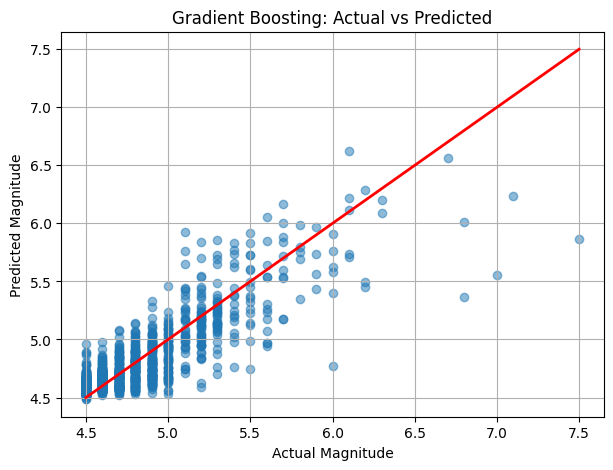

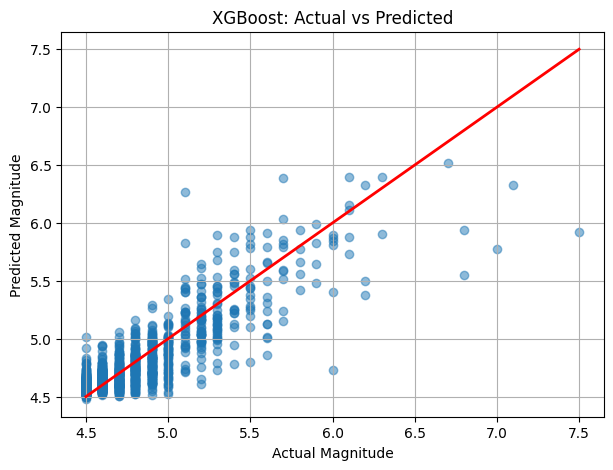

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_


🔥 Best Random Forest Params:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🔥 Best Gradient Boosting Params:
{'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.05}
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🔥 Best XGBoost Params:
{'subsample': 0.7, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}

===== TUNED MODEL RESULTS =====

📌 Tuned Random Forest PERFORMANCE
R² Score:  0.7293
RMSE:      0.1793
MAE:       0.1235
MAPE:      2.51%

📌 Tuned Gradient Boosting PERFORMANCE
R² Score:  0.7376
RMSE:      0.1765
MAE:       0.1193
MAPE:      2.42%

📌 Tuned XGBoost PERFORMANCE
R² Score:  0.7437
RMSE:      0.1744
MAE:       0.1178
MAPE:      2.39%


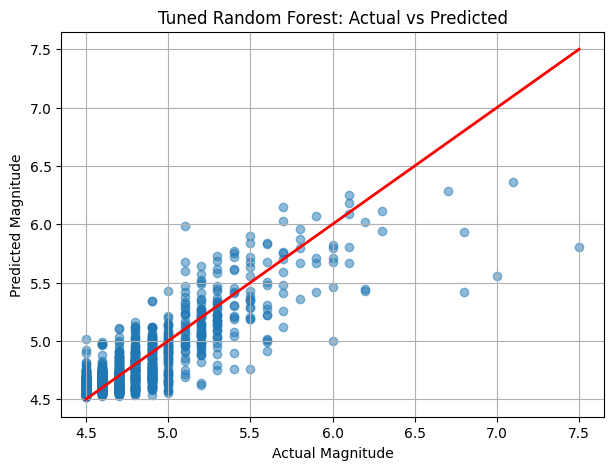

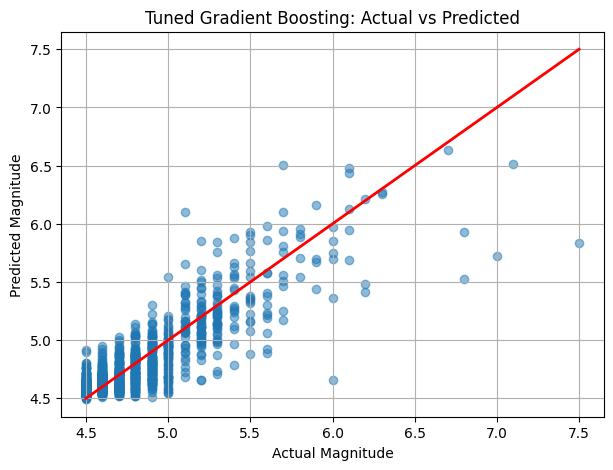

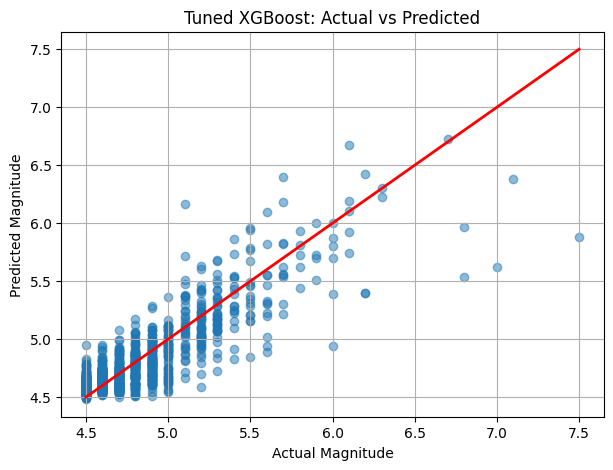


📊 FINAL PERFORMANCE COMPARISON
               Model        R²      RMSE       MAE  MAPE (%)
0      Random Forest  0.729300  0.179262  0.123484  2.508183
1  Gradient Boosting  0.737588  0.176496  0.119265  2.418746
2            XGBoost  0.743656  0.174444  0.117845  2.391583


In [ ]:

!pip install xgboost -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from google.colab import files

uploaded = files.upload()
data = pd.read_csv(next(iter(uploaded)))

print("Data Overview:")
print(data.head())

#HANDLE NAN
numeric_data = data.select_dtypes(include=[np.number]).copy()
numeric_data.dropna(subset=['mag'], inplace=True)

#MEDIAN IMPUTATION
imputer = SimpleImputer(strategy="median")
numeric_data = pd.DataFrame(imputer.fit_transform(numeric_data),
                            columns=numeric_data.columns)


if "magType" in data.columns:
    le = LabelEncoder()
    numeric_data["mag_type_encoded"] = le.fit_transform(data["magType"])
else:
    numeric_data["mag_type_encoded"] = 0

#FEATURES
numeric_data["depth_ratio"] = numeric_data["depth"] / (
    numeric_data["depth"] + numeric_data["horizontalError"] + 1
)
numeric_data["gap_weighted_rms"] = numeric_data["gap"] * numeric_data["rms"]
numeric_data["horizontal_ratio"] = numeric_data["horizontalError"] / (numeric_data["depth"] + 1)
numeric_data["gap_rms_ratio"] = numeric_data["gap"] / (numeric_data["rms"] + 1)
numeric_data["energy_proxy"] = numeric_data["mag_type_encoded"] * numeric_data["depth"]


X = numeric_data.drop(columns=["mag"], errors="ignore")
y = numeric_data["mag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#FIRST MODELS/ BASE MODELS
rf_model = RandomForestRegressor(n_estimators=150, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

xgb_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

#BASE SCORES
def evaluate_model(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100

    print(f"\n📌 {name} PERFORMANCE")
    print(f"R² Score:  {r2:.4f}")
    print(f"RMSE:      {rmse:.4f}")
    print(f"MAE:       {mae:.4f}")
    print(f"MAPE:      {mape:.2f}%")

    return r2, rmse, mae, mape

print("\n===== BASELINE MODEL RESULTS =====")
rf_scores = evaluate_model(y_test, rf_pred, "Random Forest")
gb_scores = evaluate_model(y_test, gb_pred, "Gradient Boosting")
xgb_scores = evaluate_model(y_test, xgb_pred, "XGBoost")

#FEATURE IMPORTANCE---
def plot_importance(model, title):
    plt.figure(figsize=(10, 6))
    plt.barh(X.columns, model.feature_importances_)
    plt.title(title)
    plt.show()

plot_importance(rf_model, "Random Forest Feature Importance")
plot_importance(gb_model, "Gradient Boosting Feature Importance")
plot_importance(xgb_model, "XGBoost Feature Importance")

#SCATTER PLOTS BASE
def scatter_plot(actual, predicted, title):
    plt.figure(figsize=(7,5))
    plt.scatter(actual, predicted, alpha=0.5)
    plt.plot([actual.min(), actual.max()],
             [actual.min(), actual.max()],
             color='red', linewidth=2)
    plt.xlabel("Actual Magnitude")
    plt.ylabel("Predicted Magnitude")
    plt.title(title)
    plt.grid(True)
    plt.show()

scatter_plot(y_test, rf_pred, "Random Forest: Actual vs Predicted")
scatter_plot(y_test, gb_pred, "Gradient Boosting: Actual vs Predicted")
scatter_plot(y_test, xgb_pred, "XGBoost: Actual vs Predicted")


rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=20, scoring='r2', cv=3, verbose=1,
    n_jobs=-1, random_state=42
)

rf_random_search.fit(X_train, y_train)
print("\n🔥 Best Random Forest Params:")
print(rf_random_search.best_params_)

best_rf = rf_random_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

gb_random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=20, scoring='r2', cv=3, verbose=1,
    n_jobs=-1, random_state=42
)

gb_random_search.fit(X_train, y_train)
print("\n🔥 Best Gradient Boosting Params:")
print(gb_random_search.best_params_)

best_gb = gb_random_search.best_estimator_
best_gb_pred = best_gb.predict(X_test)


xgb_param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 2]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=20, scoring='r2', cv=3, verbose=1,
    n_jobs=-1, random_state=42
)

xgb_random_search.fit(X_train, y_train)
print("\n🔥 Best XGBoost Params:")
print(xgb_random_search.best_params_)

best_xgb = xgb_random_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)

#SCORES
print("\n===== TUNED MODEL RESULTS =====")
best_rf_scores = evaluate_model(y_test, best_rf_pred, "Tuned Random Forest")
best_gb_scores = evaluate_model(y_test, best_gb_pred, "Tuned Gradient Boosting")
best_xgb_scores = evaluate_model(y_test, best_xgb_pred, "Tuned XGBoost")

#SCATTER PLOT
scatter_plot(y_test, best_rf_pred, "Tuned Random Forest: Actual vs Predicted")
scatter_plot(y_test, best_gb_pred, "Tuned Gradient Boosting: Actual vs Predicted")
scatter_plot(y_test, best_xgb_pred, "Tuned XGBoost: Actual vs Predicted")

#COMPARE
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "R²": [best_rf_scores[0], best_gb_scores[0], best_xgb_scores[0]],
    "RMSE": [best_rf_scores[1], best_gb_scores[1], best_xgb_scores[1]],
    "MAE": [best_rf_scores[2], best_gb_scores[2], best_xgb_scores[2]],
    "MAPE (%)": [best_rf_scores[3], best_gb_scores[3], best_xgb_scores[3]]
})

print("\n📊 FINAL PERFORMANCE COMPARISON")
print(comparison_df)
